# Titanic Dataset Analysis

## Part 1: Data Preparation

In this section, we load the Titanic `train` and `test` datasets, concatenate them into a single DataFrame, and perform necessary type conversions (categorical and boolean) for further analysis.

In [150]:
import pandas as pd
test_titanic = pd.read_csv('test.csv')
train_titanic = pd. read_csv('train.csv')

dat_fr = pd.concat([train_titanic, test_titanic], axis = 0, ignore_index = True)
dat_fr = pd.DataFrame(data = dat_fr)

dat_fr['Survived'] = pd.Categorical(dat_fr['Survived'])
dat_fr['Pclass'] = pd.Categorical(dat_fr['Pclass'], categories = [1, 2, 3], ordered = True)
dat_fr['Sex'] = pd.Categorical(dat_fr['Sex'])
dat_fr['Survived'] = dat_fr['Survived'].astype(bool)
dat_fr

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,False,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,True,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,True,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,True,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,False,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


## Part 2: Table Analysis

### 2.1. Basic Statistics
**Question:** Which class had the most passengers?

In [151]:
class_count = dat_fr['Pclass'].value_counts()
class_count

Pclass
3    709
1    323
2    277
Name: count, dtype: int64

### 2.2. Grouping by Class and Sex
**Question:** Grouping by Class and Sex, who is the youngest and who is the oldest on average? What is the difference?

In [152]:
grouped_by_age = dat_fr.groupby(['Pclass', 'Sex'], observed = False)['Age'].mean()
grouped_by_age

Pclass  Sex   
1       female    37.037594
        male      41.029272
2       female    27.499223
        male      30.815380
3       female    22.185329
        male      25.962264
Name: Age, dtype: float64

In [153]:
youngest_age = grouped_by_age.min()
oldest_age = grouped_by_age.max()
youngest_idx = grouped_by_age.idxmin()
oldest_idx = grouped_by_age.idxmax()
print(f"The youngest group on Titanic was: {youngest_idx[1]} from {youngest_idx[0]} class. Their average age was {youngest_age}")
print(f"The oldest group on Titanic was: {oldest_idx[1]} from {oldest_idx[0]} class. Their average age was {oldest_age}")
print(f"Age difference - {oldest_age - youngest_age}")

The youngest group on Titanic was: female from 3 class. Their average age was 22.185328947368422
The oldest group on Titanic was: male from 1 class. Their average age was 41.02927152317881
Age difference - 18.843942575810384


**Answer:**
Based on the code output above:
*   The **youngest group** consists of Females from the 3rd class.
*   The **oldest group** consists of Males from the 1st class.

### 2.3. Survivors with surname starting with "K"
**Question:** Among survivors whose names start with "K", who paid the most and who paid the least?

In [154]:
k_surv = dat_fr[(dat_fr['Survived'] == True) & (dat_fr['Name'].str.startswith('K'))].copy()
k_surv_sorted = k_surv.sort_values('Fare', ascending = False)
print(f"{k_surv_sorted.iloc[0]['Name']} paid more then everyone - {k_surv_sorted.iloc[0]['Fare']}")
print(f"{k_surv_sorted.iloc[-1]['Name']} paid less then everyone - {k_surv_sorted.iloc[-1]['Fare']}")

Kimball, Mr. Edwin Nelson Jr paid more then everyone - 52.5542
Kelly, Miss. Mary paid less then everyone - 7.75


### 2.4. Relatives Analysis
**Question:** What was the maximum number of relatives (SibSp + Parch) associated with a survived passenger?

In [165]:
survived = dat_fr[dat_fr['Survived'] == True]
dat_fr['allRelatives'] = dat_fr['Parch'] + dat_fr['SibSp']
max_relatives = survived['allRelatives'].max()
print(f"Max relatives with the person was: {max_relatives}")

Max relatives with the person was: 6


## Part 3: Visualization

In this section, we visualize the data using Plotly, Matplotlib, and Seaborn.

### 3.1. Scatter Plot: Cost vs. Age (Interactive)
Visualizing the dependence of ticket cost on age, colored by survival status.

In [156]:
import plotly.express as px

graph1 = px.scatter(dat_fr, x = 'Age', y = 'Fare', color = 'Survived',
                    size = 'Pclass', hover_data = ['Name', 'Sex'],
                    title = "Dependence of cost on age")
graph1.show()

### 3.2. Histogram: Age Distribution (Interactive)
Distribution of passengers by age, colored by sex.

In [157]:
graph2 = px.histogram(dat_fr, x = 'Age', color = 'Sex', nbins = 30,
                      title = 'distribution by age')
graph2.show()

### 3.3. Bar Chart: Survival Count by Class and Sex (Seaborn)
A static bar chart showing the absolute count of survivors grouped by class and sex.

/tmp/ipykernel_9462/101999797.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



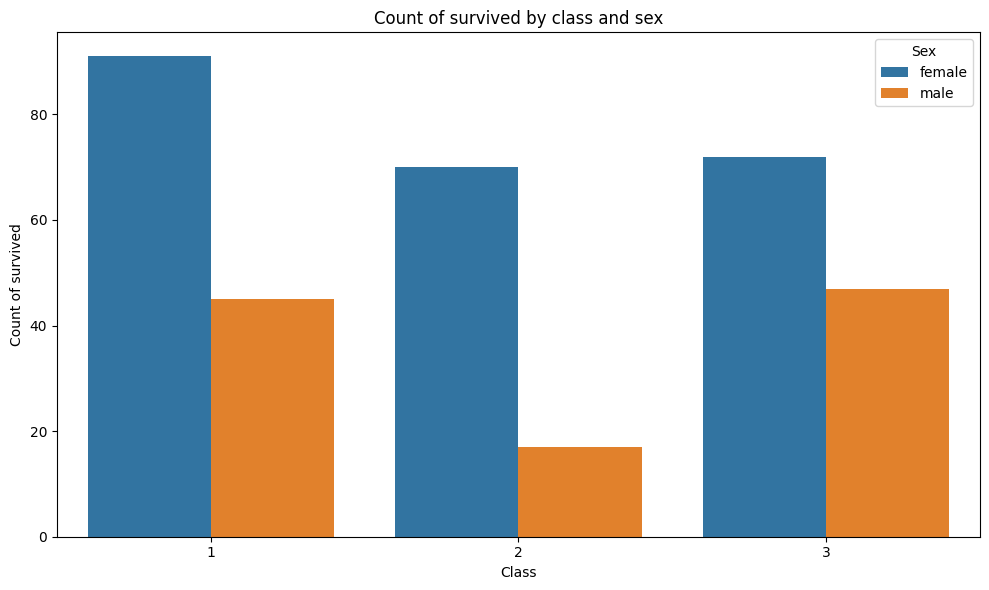

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns
survival_stats = dat_fr.groupby(['Pclass', 'Sex'])['Survived'].apply(lambda x: (x == True).sum()).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=survival_stats, x='Pclass', y='Survived', hue='Sex')
plt.title('Count of survived by class and sex')
plt.xlabel('Class')
plt.ylabel('Count of survived')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

### 3.4. Horizontal Bar Chart: Top 10 Ticket Prices
Visualizing the passengers who paid the highest fares.

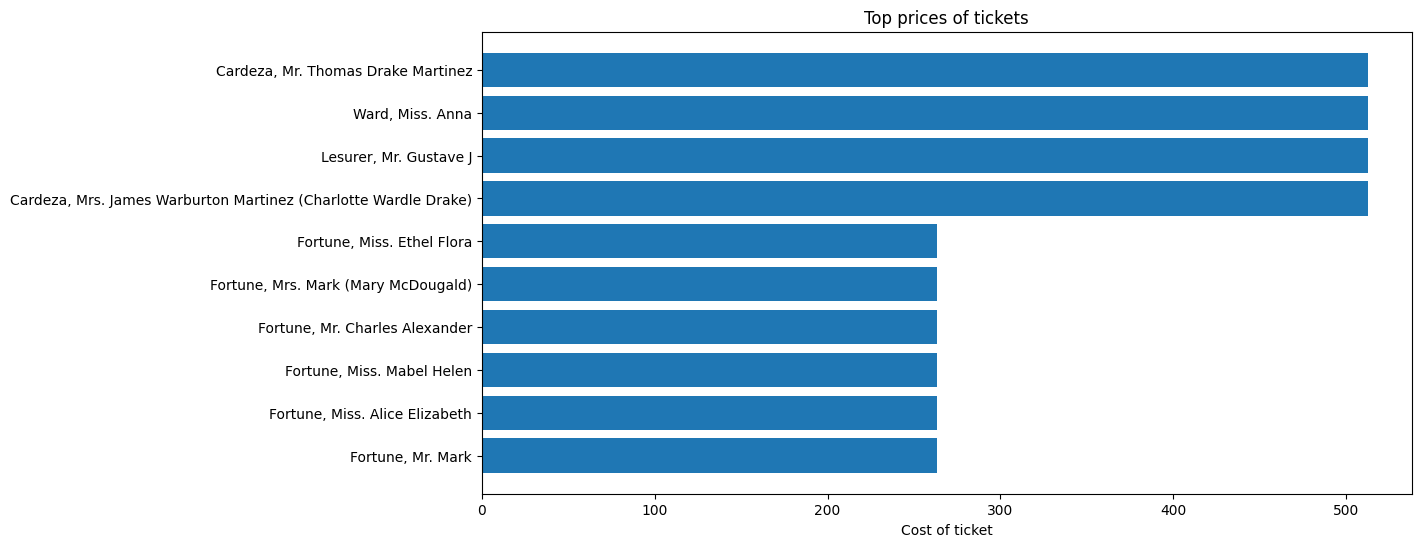

In [159]:
top_ticket_prices = dat_fr.nlargest(10, 'Fare')[['Name', 'Fare']].sort_values('Fare')
plt.figure(figsize=(12, 6))
plt.barh(range(len(top_ticket_prices)), top_ticket_prices['Fare'])
plt.yticks(range(len(top_ticket_prices)), [name for name in top_ticket_prices['Name']])
plt.xlabel('Cost of ticket')
plt.title('Top prices of tickets')
plt.show()

### 3.5. Pie Chart: Class Distribution (Interactive)
Showing the proportion of passengers in each class.

In [160]:
class_distribution = dat_fr['Pclass'].value_counts()
graph5 = px.pie(values=class_distribution.values, names=class_distribution.index,
              title='Distribution by class')
graph5.show()

### 3.6. Sunburst Chart: Survivability Hierarchy (Interactive)
Hierarchical view of survivors by Class, then Sex, then Survival status.

In [161]:
survived_data = dat_fr.dropna(subset = ['Survived'])
graph6 = px.sunburst(survived_data, path=['Pclass', 'Sex', 'Survived'],
                   title='Survivability by class')
graph6.show()

### 3.7. 3D Scatter Plot (Interactive)
3D visualization comparing Age, Ticket Cost, and Number of Relatives.

In [162]:
import plotly.graph_objects as go
dat_fr['Survived'] = pd.Categorical(dat_fr['Survived'])

graph7 = go.Figure(data = [go.Scatter3d(x = dat_fr['Age'], y = dat_fr['Fare'], z = dat_fr['allRelatives'], mode = 'markers',
    marker=dict(size = 5, color = dat_fr ['Survived'].cat.codes, colorscale = 'Viridis', showscale = True, colorbar =dict (title="survived")), text = dat_fr['Name'], hovertemplate='<b>%{text}</b><br>age: %{x}<br>cost: %{y}<br>relatives: %{z}<extra></extra>')])

graph7.update_layout(title='3D visualisation: age, cost af ticket and quantity of relatives',
    scene = dict(xaxis_title = 'Age', yaxis_title = 'cost of ticket', zaxis_title = 'quantity of relatives'))
graph7.show()